# Final Model 2 - FINANCIAL

In [ ]:
# Cell 1: Import Libraries and Load Data from Google Drive
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the file path (update if necessary)
file_path = r"/content/drive/My Drive/Yr5/Cuatri2/TFG: Capstone project/Data1.xlsx"

# Load the dataset
data = pd.read_excel(file_path)
data.head()


Mounted at /content/drive


,Patient number,Gender,Age,Operation,Method,Complications,Hospital stay (days),Surgery type,ASA Score
0,1,Male,45,Cholecystectomy,Laparoscopic,NaN,1,Urgent,2
1,2,Male,58,Cholecystectomy,Laparoscopic,NaN,0,Urgent,2
2,3,Female,43,Cholecystectomy,Laparoscopic,NaN,0,Planned,2
3,4,Female,11,Cholecystectomy,Laparoscopic,NaN,1,Urgent,1
4,5,Male,18,Cholecystectomy,Laparoscopic,Organ damage,2,Urgent,2


In [ ]:
# Cell 2: Clean and Prepare the Data

# Ensure the "Method" column is consistently capitalized (e.g., "Laparoscopic" or "Open")
data["Method"] = data["Method"].astype(str).str.strip().str.capitalize()

# Replace missing values or "None" in the "Complications" column with "No complications"
data["Complications"] = data["Complications"].fillna("No complications")
data["Complications"] = data["Complications"].replace("None", "No complications")

# Display the first few rows to verify changes
data.head()

,Patient number,Gender,Age,Operation,Method,Complications,Hospital stay (days),Surgery type,ASA Score
0,1,Male,45,Cholecystectomy,Laparoscopic,No complications,1,Urgent,2
1,2,Male,58,Cholecystectomy,Laparoscopic,No complications,0,Urgent,2
2,3,Female,43,Cholecystectomy,Laparoscopic,No complications,0,Planned,2
3,4,Female,11,Cholecystectomy,Laparoscopic,No complications,1,Urgent,1
4,5,Male,18,Cholecystectomy,Laparoscopic,Organ damage,2,Urgent,2


In [ ]:
# Cell 3: Calculate Average Hospital Stay by Surgical Method
avg_stay = data.groupby("Method")["Hospital stay (days)"].mean()
print("Average Hospital Stay by Method:")
print(avg_stay)

Average Hospital Stay by Method:
Method
Laparoscopic    1.135729
Open            6.791583
Name: Hospital stay (days), dtype: float64


In [ ]:
# Cell 4: Calculate Number of Complications Overall and by Type per Surgical Method

# Filter the dataset to include only rows with complications (i.e., not "No complications")
complications = data[data["Complications"] != "No complications"]

# Calculate overall number of complications by surgical method
comp_count_by_method = complications.groupby("Method").size()
print("Number of Complications by Method:")
print(comp_count_by_method)

# Calculate number of complications by type for each method
complications_by_type = complications.groupby(["Method", "Complications"]).size().unstack(fill_value=0)
print("\nComplications by Type and Method:")
print(complications_by_type)

Number of Complications by Method:
Method
Laparoscopic     29
Open            252
dtype: int64

Complications by Type and Method:
Complications  Bleeding  Infection  Organ damage  Reoperation
Method                                                       
Laparoscopic         16          0            13            0
Open                 24        186            16           26


In [ ]:
# Cell 4.1: Calculate and Display Complication Percentages

# Calculate the total number of surgeries per method
total_patients = data.groupby("Method").size()
print("Total Surgeries by Method:")
print(total_patients)

# Calculate the percentage of patients with any complication by method
comp_percentage_by_method = (comp_count_by_method / total_patients) * 100
print("\nPercentage of Patients with Complications by Method:")
print(comp_percentage_by_method)

# Calculate the percentage breakdown of each complication type per method.
# Divide each count in complications_by_type by the total patients for that method and multiply by 100.
complications_by_type_percentage = complications_by_type.divide(total_patients, axis=0) * 100
print("\nPercentage Breakdown of Each Complication Type by Method:")
print(complications_by_type_percentage)


Total Surgeries by Method:
Method
Laparoscopic    501
Open            499
dtype: int64

Percentage of Patients with Complications by Method:
Method
Laparoscopic     5.788423
Open            50.501002
dtype: float64

Percentage Breakdown of Each Complication Type by Method:
Complications  Bleeding  Infection  Organ damage  Reoperation
Method                                                       
Laparoscopic   3.193613   0.000000      2.594810     0.000000
Open           4.809619  37.274549      3.206413     5.210421


In [ ]:
# Cell 5: Count Reoperations by Surgical Method (if applicable)

if "Reoperation" in complications["Complications"].unique():
    reoperation_count = complications[complications["Complications"] == "Reoperation"].groupby("Method").size()
    print("Number of Reoperations by Method:")
    print(reoperation_count)
else:
    print("No 'Reoperation' complication type found.")


Number of Reoperations by Method:
Method
Open    26
dtype: int64


In [ ]:
# Cell 6: Simulate Cost Analysis and Compute Turnover Rate

# Assumptions
cost_per_day = 633
cost_reoperation = 4000
cost_other = 1000

# Total number of patients by method
patients_by_method = data.groupby("Method").size()
print("Patients by Method:")
print(patients_by_method)

# Calculate hospital stay cost by method:
stay_cost = avg_stay * patients_by_method * cost_per_day
print("\nHospital Stay Cost by Method ($):")
print(stay_cost)

# Function to assign cost based on complication type
def cost_of_complication(comp_type):
    if comp_type == "Reoperation":
        return cost_reoperation
    else:
        return cost_other

# Calculate complication cost per method:
# Multiply each complication count by its corresponding cost.
complications_cost = complications_by_type.copy()
for comp in complications_cost.columns:
    complications_cost[comp] = complications_cost[comp] * cost_of_complication(comp)

total_comp_cost = complications_cost.sum(axis=1)
print("\nTotal Complication Cost by Method ($):")
print(total_comp_cost)

# Total cost is the sum of hospital stay cost and complication cost.
total_cost = stay_cost + total_comp_cost
print("\nTotal Cost by Method ($):")
print(total_cost)

# Compute a simple bed turnover metric: lower average stay means higher turnover.
turnover_rate = 1 / avg_stay
print("\nTurnover Rate (Patients per day per bed):")
print(turnover_rate)


Patients by Method:
Method
Laparoscopic    501
Open            499
dtype: int64

Hospital Stay Cost by Method ($):
Method
Laparoscopic     360177.0
Open            2145237.0
dtype: float64

Total Complication Cost by Method ($):
Method
Laparoscopic     29000
Open            330000
dtype: int64

Total Cost by Method ($):
Method
Laparoscopic     389177.0
Open            2475237.0
dtype: float64

Turnover Rate (Patients per day per bed):
Method
Laparoscopic    0.880492
Open            0.147241
Name: Hospital stay (days), dtype: float64


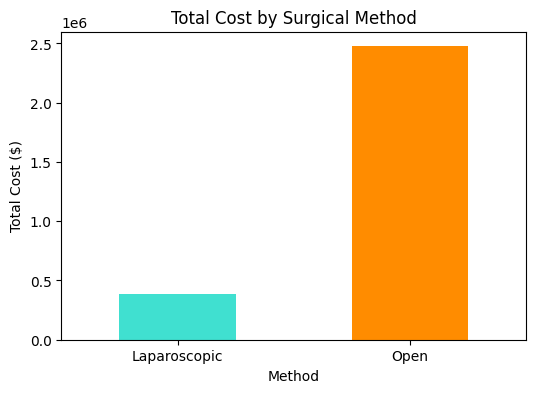

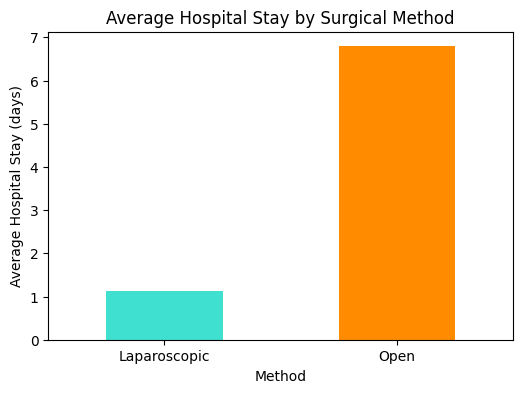

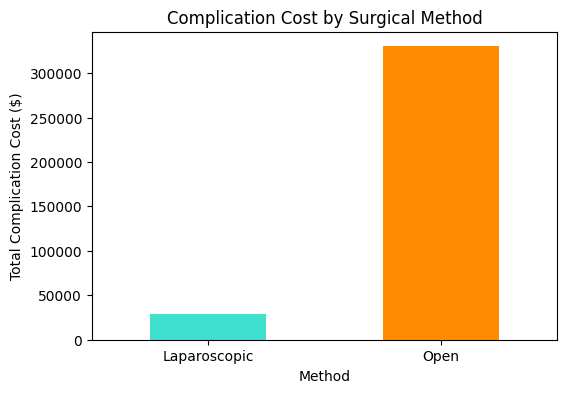

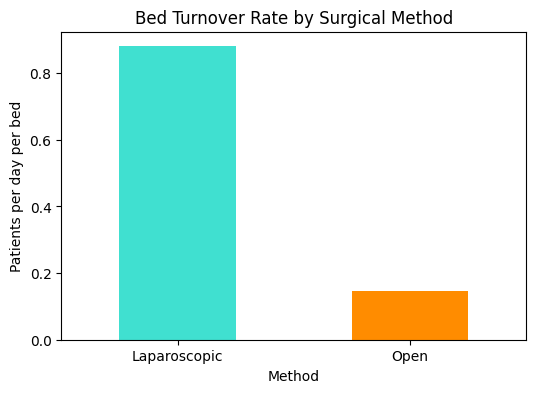

In [ ]:
# Cell 7: Visualize the Results with Updated Colors
import matplotlib.pyplot as plt

# Define colors
open_color = "#40E0D0"    # Dark Orange
lap_color = "#FF8C00"     # Turquoise

# 7a) Bar plot: Total Cost by Surgical Method
plt.figure(figsize=(6,4))
total_cost.plot(kind="bar", color=[open_color, lap_color])
plt.ylabel("Total Cost ($)")
plt.title("Total Cost by Surgical Method")
plt.xticks(rotation=0)
plt.show()

# 7b) Bar plot: Average Hospital Stay by Method
plt.figure(figsize=(6,4))
avg_stay.plot(kind="bar", color=[open_color, lap_color])
plt.ylabel("Average Hospital Stay (days)")
plt.title("Average Hospital Stay by Surgical Method")
plt.xticks(rotation=0)
plt.show()

# 7c) Bar plot: Total Complication Cost by Method
plt.figure(figsize=(6,4))
total_comp_cost.plot(kind="bar", color=[open_color, lap_color])
plt.ylabel("Total Complication Cost ($)")
plt.title("Complication Cost by Surgical Method")
plt.xticks(rotation=0)
plt.show()

# 7d) Bar plot: Turnover Rate by Method
plt.figure(figsize=(6,4))
turnover_rate.plot(kind="bar", color=[open_color, lap_color])
plt.ylabel("Patients per day per bed")
plt.title("Bed Turnover Rate by Surgical Method")
plt.xticks(rotation=0)
plt.show()


In a month

Monthly Open Surgeries (scenario): 60
Monthly Laparoscopic Surgeries (scenario): 180

Cost per Open Surgery (from dataset): 4960.394789579158
Cost per Laparoscopic Surgery (from dataset): 776.8003992015969

--- Monthly Cost Scenarios ---
Open-Only Scenario (per month): $297,623.69
Laparoscopic-Only Scenario (per month): $139,824.07

Scenario Comparison:
                       Monthly Surgeries  Cost per Surgery  Monthly Total Cost
Open Scenario                         60       4960.394790       297623.687375
Laparoscopic Scenario                180        776.800399       139824.071856


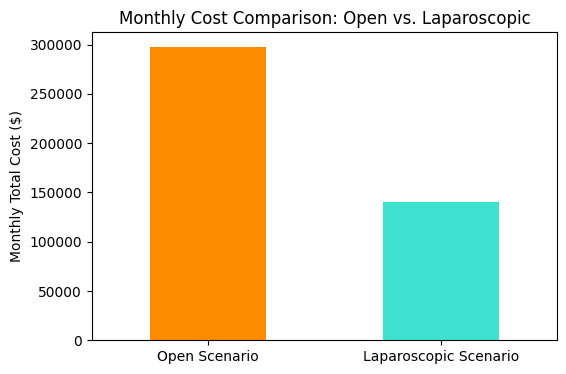

In [ ]:
# Cell 8: Scenario-Based Monthly Cost Analysis (with Updated Colors)

# 1) Define daily capacity and monthly horizon
days_in_month = 30
daily_capacity_open = 2   # e.g., 2 open surgeries per day
daily_capacity_lap = 6    # e.g., 6 laparoscopic surgeries per day

monthly_surgeries_open = daily_capacity_open * days_in_month
monthly_surgeries_lap = daily_capacity_lap * days_in_month

print(f"Monthly Open Surgeries (scenario): {monthly_surgeries_open}")
print(f"Monthly Laparoscopic Surgeries (scenario): {monthly_surgeries_lap}")

# 2) Compute the average (per-patient) total cost for each method from our prior analysis
#    total_cost["Open"] is the total cost for ALL open surgeries in the dataset.
#    patients_by_method["Open"] is how many open surgeries are in the dataset.
#    So cost_per_open_surgery is total_cost["Open"] / number_of_open_surgeries.
cost_per_open_surgery = total_cost["Open"] / patients_by_method["Open"]
cost_per_lap_surgery = total_cost["Laparoscopic"] / patients_by_method["Laparoscopic"]

print("\nCost per Open Surgery (from dataset):", cost_per_open_surgery)
print("Cost per Laparoscopic Surgery (from dataset):", cost_per_lap_surgery)

# 3) Calculate monthly total cost for each scenario
monthly_cost_open = cost_per_open_surgery * monthly_surgeries_open
monthly_cost_lap = cost_per_lap_surgery * monthly_surgeries_lap

print("\n--- Monthly Cost Scenarios ---")
print(f"Open-Only Scenario (per month): ${monthly_cost_open:,.2f}")
print(f"Laparoscopic-Only Scenario (per month): ${monthly_cost_lap:,.2f}")

# 4) Compare the two scenarios in a small DataFrame
scenario_comparison = pd.DataFrame({
    "Monthly Surgeries": [monthly_surgeries_open, monthly_surgeries_lap],
    "Cost per Surgery": [cost_per_open_surgery, cost_per_lap_surgery],
    "Monthly Total Cost": [monthly_cost_open, monthly_cost_lap]
}, index=["Open Scenario", "Laparoscopic Scenario"])

print("\nScenario Comparison:")
print(scenario_comparison)

# 5) (Optional) Quick bar plot to visualize monthly cost difference with updated colors
import matplotlib.pyplot as plt

# Define colors: dark orange for Open and turquoise for Laparoscopic
open_color = "#FF8C00"
lap_color = "#40E0D0"

plt.figure(figsize=(6,4))
scenario_comparison["Monthly Total Cost"].plot(kind="bar", color=[open_color, lap_color])
plt.ylabel("Monthly Total Cost ($)")
plt.title("Monthly Cost Comparison: Open vs. Laparoscopic")
plt.xticks(rotation=0)
plt.show()


Revenue analysis assuming revenue per surgery is 60€ for open and 46 for laparoscopic

In [ ]:
# Cell 9: Revenue Analysis

# Assumed procedure revenue per surgery (in euros)
revenue_open = 2000
revenue_lap = 3500

# Compute average complication cost per surgery for each method
avg_comp_cost_open = total_comp_cost["Open"] / patients_by_method["Open"]
avg_comp_cost_lap = total_comp_cost["Laparoscopic"] / patients_by_method["Laparoscopic"]

print("Average Complication Cost per Open Surgery: €{:.2f}".format(avg_comp_cost_open))
print("Average Complication Cost per Laparoscopic Surgery: €{:.2f}".format(avg_comp_cost_lap))

# Net revenue per surgery = procedure revenue minus average complication cost
net_revenue_open = revenue_open - avg_comp_cost_open
net_revenue_lap = revenue_lap - avg_comp_cost_lap

print("\nNet Revenue per Open Surgery: €{:.2f}".format(net_revenue_open))
print("Net Revenue per Laparoscopic Surgery: €{:.2f}".format(net_revenue_lap))

# Using the same daily capacity assumptions as before (Cell 8):
days_in_month = 30
daily_capacity_open = 2   # open surgeries per day
daily_capacity_lap = 6    # laparoscopic surgeries per day

monthly_surgeries_open = daily_capacity_open * days_in_month
monthly_surgeries_lap = daily_capacity_lap * days_in_month

# Monthly net revenue for each scenario:
monthly_net_rev_open = net_revenue_open * monthly_surgeries_open
monthly_net_rev_lap = net_revenue_lap * monthly_surgeries_lap

print("\nMonthly Net Revenue (Open-Only Scenario): €{:.2f}".format(monthly_net_rev_open))
print("Monthly Net Revenue (Laparoscopic-Only Scenario): €{:.2f}".format(monthly_net_rev_lap))


Average Complication Cost per Open Surgery: €661.32
Average Complication Cost per Laparoscopic Surgery: €57.88

Net Revenue per Open Surgery: €1338.68
Net Revenue per Laparoscopic Surgery: €3442.12

Monthly Net Revenue (Open-Only Scenario): €80320.64
Monthly Net Revenue (Laparoscopic-Only Scenario): €619580.84


Opportunity cost

In [ ]:
# Cell 10: Opportunity Cost of Complications (Extended Recovery Cost)

# Assumptions for additional recovery days due to complications
extra_days_other = 2   # extra days for any non-reoperation complication
extra_days_reoperation = 5  # extra days for reoperation complications

# Calculate additional recovery cost per complication type (in euros)
# using the cost_per_day defined previously
extra_cost_other = extra_days_other * cost_per_day
extra_cost_reoperation = extra_days_reoperation * cost_per_day

# Create a copy of complications_by_type for opportunity cost calculations
opportunity_cost = complications_by_type.copy()

# For each complication type, assign the extra recovery cost
for comp in opportunity_cost.columns:
    if comp == "Reoperation":
        opportunity_cost[comp] = opportunity_cost[comp] * extra_cost_reoperation
    else:
        opportunity_cost[comp] = opportunity_cost[comp] * extra_cost_other

# Sum the additional recovery cost per method
extra_recovery_cost = opportunity_cost.sum(axis=1)
print("Extra Recovery Cost due to Complications by Method (Opportunity Cost):")
print(extra_recovery_cost)

# Compute the average extra recovery cost per surgery for each method
avg_extra_cost_per_surgery = extra_recovery_cost / patients_by_method
print("\nAverage Extra Recovery Cost per Surgery (Opportunity Cost):")
print(avg_extra_cost_per_surgery)

# Calculate monthly extra recovery cost for each scenario
monthly_extra_cost_open = avg_extra_cost_per_surgery["Open"] * monthly_surgeries_open
monthly_extra_cost_lap = avg_extra_cost_per_surgery["Laparoscopic"] * monthly_surgeries_lap

print("\nMonthly Extra Recovery Cost (Opportunity Cost):")
print(f"Open Surgeries: €{monthly_extra_cost_open:,.2f}")
print(f"Laparoscopic Surgeries: €{monthly_extra_cost_lap:,.2f}")


Extra Recovery Cost due to Complications by Method (Opportunity Cost):
Method
Laparoscopic     36714
Open            368406
dtype: int64

Average Extra Recovery Cost per Surgery (Opportunity Cost):
Method
Laparoscopic     73.281437
Open            738.288577
dtype: float64

Monthly Extra Recovery Cost (Opportunity Cost):
Open Surgeries: €44,297.31
Laparoscopic Surgeries: €13,190.66


Sensitivity analysis

In [ ]:
# Cell 11: Sensitivity Analysis on Cost per Hospital Day
import numpy as np

# We’ll vary cost_per_day (in euros) from 800 to 1200
sensitivity_results = []

# Fixed daily capacities (same as before)
fixed_open_capacity = 2   # open surgeries per day
fixed_lap_capacity = 6    # laparoscopic surgeries per day
monthly_open = fixed_open_capacity * 30  # 30-day month
monthly_lap = fixed_lap_capacity * 30

# We'll assume the baseline cost_per_day used previously was 1000€
for cp in [800, 1000, 1200]:
    # Recalculate hospital stay cost for each method using the new cost per day
    new_stay_cost_open = avg_stay["Open"] * patients_by_method["Open"] * cp
    new_stay_cost_lap = avg_stay["Laparoscopic"] * patients_by_method["Laparoscopic"] * cp

    # Adjust complication costs assuming they scale linearly with cost_per_day.
    new_total_comp_cost_open = total_comp_cost["Open"] * (cp / 1000)
    new_total_comp_cost_lap = total_comp_cost["Laparoscopic"] * (cp / 1000)

    # Total cost per surgery = (hospital stay cost + complication cost) divided by number of surgeries
    total_cost_per_open = (new_stay_cost_open + new_total_comp_cost_open) / patients_by_method["Open"]
    total_cost_per_lap = (new_stay_cost_lap + new_total_comp_cost_lap) / patients_by_method["Laparoscopic"]

    # Net revenue per surgery: procedure revenue minus total cost per surgery
    net_rev_open = revenue_open - total_cost_per_open
    net_rev_lap = revenue_lap - total_cost_per_lap

    # Monthly net revenue: multiply net revenue per surgery by number of surgeries performed in a month
    monthly_net_rev_open = net_rev_open * monthly_open
    monthly_net_rev_lap = net_rev_lap * monthly_lap

    sensitivity_results.append({
        "cost_per_day": cp,
        "Net_Revenue_Per_Open": net_rev_open,
        "Net_Revenue_Per_Lap": net_rev_lap,
        "Monthly_Net_Revenue_Open": monthly_net_rev_open,
        "Monthly_Net_Revenue_Lap": monthly_net_rev_lap
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
print(sensitivity_df)


   cost_per_day  Net_Revenue_Per_Open  Net_Revenue_Per_Lap  \
0           800          -3962.324649          2545.109780   
1          1000          -5452.905812          2306.387226   
2          1200          -6943.486974          2067.664671   

   Monthly_Net_Revenue_Open  Monthly_Net_Revenue_Lap  
0            -237739.478958            458119.760479  
1            -327174.348697            415149.700599  
2            -416609.218437            372179.640719  


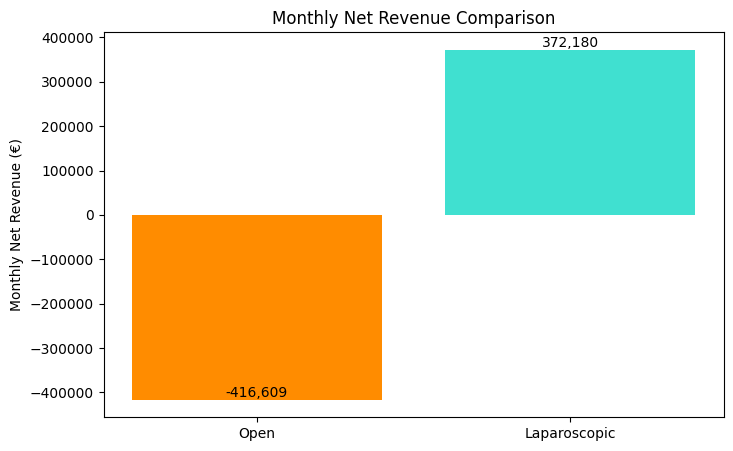

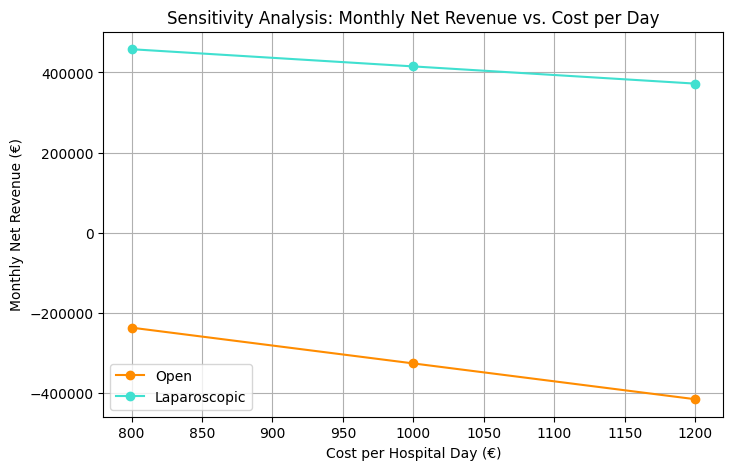

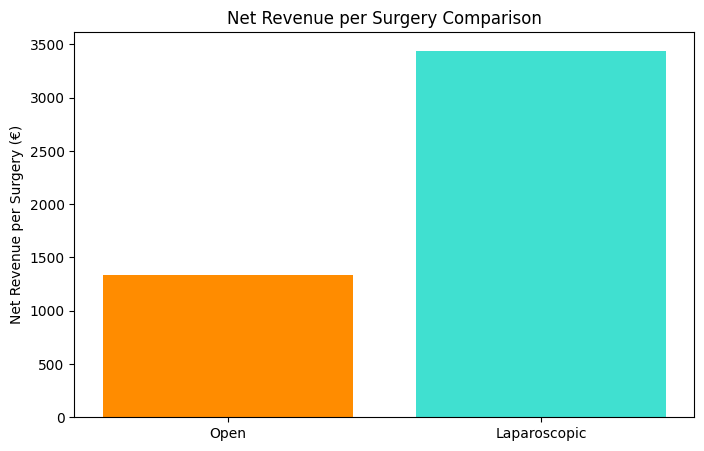

In [ ]:
# Cell 12: Graphical Comparisons with Updated Colors

import matplotlib.pyplot as plt

# Define colors
open_color = "#FF8C00"       # light orange
lap_color = "#40E0D0"        # turquoise

# Graph 1: Monthly Net Revenue Comparison
plt.figure(figsize=(8,5))
methods = ["Open", "Laparoscopic"]
monthly_net_revenues = [monthly_net_rev_open, monthly_net_rev_lap]
bars = plt.bar(methods, monthly_net_revenues, color=[open_color, lap_color])
plt.ylabel("Monthly Net Revenue (€)")
plt.title("Monthly Net Revenue Comparison")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:,.0f}", ha='center', va='bottom')
plt.show()

# Graph 2: Sensitivity Analysis Plot
plt.figure(figsize=(8,5))
plt.plot(sensitivity_df["cost_per_day"], sensitivity_df["Monthly_Net_Revenue_Open"],
         marker='o', color=open_color, label="Open")
plt.plot(sensitivity_df["cost_per_day"], sensitivity_df["Monthly_Net_Revenue_Lap"],
         marker='o', color=lap_color, label="Laparoscopic")
plt.xlabel("Cost per Hospital Day (€)")
plt.ylabel("Monthly Net Revenue (€)")
plt.title("Sensitivity Analysis: Monthly Net Revenue vs. Cost per Day")
plt.legend()
plt.grid(True)
plt.show()

# Graph 3: Net Revenue per Surgery Comparison
plt.figure(figsize=(8,5))
net_revenues_per_surgery = [net_revenue_open, net_revenue_lap]
plt.bar(methods, net_revenues_per_surgery, color=[open_color, lap_color])
plt.ylabel("Net Revenue per Surgery (€)")
plt.title("Net Revenue per Surgery Comparison")
plt.show()
